<div style="text-align: center;">

# Stable Diffusion for Synthetic Electrochemical Image Generation

</div>

**Author**: Dr. Amir Omidvarnia  
**Email**: a.omidvarnia@fz-juelich.de  
**Affiliation**: Forschungszentrum Jülich, Germany  
**Event**: DPG2026 AKPIK tutorial on ML-based image processing for electrochemical applications (7 March 2026)

---

## Overview

**Stable Diffusion** (SD) is a latent diffusion model (LDM) that generates high-resolution images by iteratively denoising a latent representation in a compressed image space learned by a variational autoencoder (VAE). Conditioning on text prompts or reference images guides the denoising trajectory, allowing the model to produce samples that satisfy both the data distribution learned during pretraining and the provided structural or semantic constraints.

### Why Stable Diffusion for electrochemical images?

- **High image quality**: SD produces photorealistic textures and complex structural patterns that simple augmentation or even GANs struggle to match.
- **Image-guided conditioning**: using a real SEM image as a conditioning input, SD can generate structurally related variants — new frames that share the same microstructural motifs but differ in fine-grained detail.
- **Scalability**: a small number of reference images can seed a large and diverse synthetic dataset.

### How synthetic masks are derived

Unlike physics-based generation (which analytically derives masks) or augmentation (which preserves real masks), SD-based synthesis requires a separate step to produce segmentation labels. Masks are typically derived from the diffusion strength or by thresholding the generated images — their quality therefore depends on both the generative model fidelity and the mask-derivation strategy.

### Workflow

1. Load configuration (diffusion hyperparameters: guidance scale, number of inference steps, image resolution, prompt templates).
2. Prepare the input images and initialize the Stable Diffusion generator.
3. Run the denoising pipeline to produce synthetic electrochemical images.
4. Visually inspect the generated images and their derived masks for structural realism.

### Goal of This Notebook

This notebook investigates how a Stable Diffusion–based generative model can be adapted to synthesize electron microscopy–like images, enabling controlled exploration of text- and image-guided priors for augmenting electrochemical datasets beyond purely physics-based or GAN-based approaches.


### Experimental Context and Repository Setup


This cell defines the Stable Diffusion synthesis experiment by specifying the dataset, number of input images, and method name, and by binding the notebook to the local DPG2026 repository so that all subsequent generation uses a version-controlled implementation.
From a methodological perspective, it anchors the diffusion-based generative process to a well-defined corpus of electron microscopy data and code, which is essential for reproducible comparisons against physics-based and GAN-based generators.

In [1]:
# Import necessary modules
from pathlib import Path
import sys
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch
import logging

# !!!!!!!!!!!!!!!!!!!!!! Be careful with the force flag !!!!!!!!!!!!!!!!!!!!!!
force=True  # Force re-preparation of directories and models
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# Define method name and number of images for training
method_name = 'SDiff'
N_images = 10  # Number of input images to be synthesized by the model
dataset = 'dataset_PB'

# Set the path to include the repository root
try:
    notebook_dir = Path(__file__).resolve().parent
except Exception:
    notebook_dir = Path.cwd()

cur = notebook_dir
repo_root = None
for _ in range(6):
    if (cur / 'src').exists():
        repo_root = cur
        break
    if cur.parent == cur:
        break
    cur = cur.parent

if repo_root is None:
    repo_root = Path.cwd()

modules_dir = repo_root / 'src'
repo_root_str = str(repo_root)
if repo_root_str not in sys.path:
    sys.path.insert(0, repo_root_str)
print(f'Added repo root to sys.path: {repo_root_str} (src dir: {modules_dir})')

from src.synth_data_module import SynthDataGenerator
from src.synth_data_module import ConfigLoader
from src.synth_data_module import PreparationManager

Added repo root to sys.path: /Users/amir/GIT_repositories/DPG2026_release (modules dir: /Users/amir/GIT_repositories/DPG2026_release/modules)


/Users/amir/GIT_repositories/DPG2026_release/.dpg2026/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Computational Backend and Logging


Here we configure logging and select the numerical backend (CPU, GPU, or Apple Silicon accelerators), which determines both the computational budget and the temporal resolution at which we can observe the diffusion process.
Fixing the device and logging level in this way turns the Stable Diffusion run into a controlled numerical experiment whose behaviour can be compared across different hardware and parameter settings.

In [2]:
# Logging configuration
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

# Set device for PyTorch
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
    
logging.info(f"Using device: {device}.")


25:02:2026 15:37:13 - Using device: mps.


### Stable Diffusion Configuration


This block loads a YAML configuration that encodes Stable Diffusion–specific parameters and global dataset properties, such as image resolution and prompt templates.
By treating these entries as explicit experimental factorsrather than hard-coded defaultswe can systematically explore how guidance scale, diffusion strength, and other hyperparameters shape the realism and diversity of the synthesized electrochemical microstructures.

In [3]:
# Load configuration from YAML file
config_path = repo_root / 'tutorial_parameters.yaml'
config = ConfigLoader(config_path)
logging.info(f"Configuration loaded from: {config_path}")

25:02:2026 15:37:13 - Configuration loaded from: /Users/amir/GIT_repositories/DPG2026_release/tutorial_parameters.yaml


### Data Pipeline and Generator Initialization


In this step, the Stable Diffusion generator is instantiated and connected to preprocessed electron microscopy images, defining how each input frame will be transformed into a small ensemble of synthetic variants.
Conceptually, this couples a finite empirical dataset to a powerful latent diffusion model, specifying how structure in the original micrographs is propagated and diversified in the synthetic image space.

In [4]:
# Ensure required top-level config keys exist (provide sensible defaults if missing)
cfg_dict = getattr(config, 'config', None)
if cfg_dict is None:
    raise RuntimeError('ConfigLoader did not load a configuration dictionary.')
import os
if 'synth_models_dir' not in cfg_dict:
    cfg_dict['synth_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'synth_models')
if 'segmentation_models_dir' not in cfg_dict:
    cfg_dict['segmentation_models_dir'] = os.path.join(cfg_dict.get('models_dir', os.getcwd()), 'segmentation_models')
# Re-wrap config back into ConfigLoader if necessary (ConfigLoader keeps reference to cfg_dict)
prep_manager_sdiff = PreparationManager(config=config, input_dataset=dataset, method_name=method_name, force=force)

# Use only 200 training images for demonstration (Stable Diffusion is slow)
generator = SynthDataGenerator(
    prep_manager=prep_manager_sdiff,
    config=config,
    method_name=method_name,
    N_images=N_images,
    device=device
)

print(f"Initialized SynthDataGenerator for {method_name}")
print(f"Using {N_images} training images")
print(f"\nNote: Stable Diffusion generation may take several minutes...")

Initialized SynthDataGenerator for SDiff
Using 10 training images

Note: Stable Diffusion generation may take several minutes...


### Diffusion-Based Synthesis Run


This section triggers the full Stable Diffusion pipeline, iteratively denoising latent representations conditioned on the input images and prompts to produce electron microscopylike samples.
From a theoretical viewpoint, each run corresponds to sampling from an implicit probabilistic model over images, allowing us to explore the range of microstructural patterns that are consistent with both the training data and the chosen textual or structural priors.

In [5]:
# Upgrade packages to meet Stable Diffusion requirements
# %pip install --upgrade transformers diffusers accelerate

# Generate synthetic images
print("Starting Stable Diffusion generation...")
generator.generate()
print("\nGeneration complete!")

25:02:2026 15:37:13 - Generating synthetic images using Stable Diffusion model ...
25:02:2026 15:37:13 - Parameters for the Stable Diffusion model were set.
25:02:2026 15:37:13 - Initial parameters and file/folder paths were set.
25:02:2026 15:37:13 - Preprocessing training images...


Starting Stable Diffusion generation...


Preprocessing images: 100%|██████████| 10/10 [00:00<00:00, 132.96it/s]
25:02:2026 15:37:13 - Training images and masks were preprocessed.
25:02:2026 15:37:13 - Test images and masks were preprocessed.
25:02:2026 15:37:13 - *******************
25:02:2026 15:37:13 - Using device: mps for Stable Diffusion model.


Preprocessing complete.
Images saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/SDiff_dataset_PB/input_images
Masks saved to: /Users/amir/Documents/DPG2026_Tutorial/preprocessed_data/SDiff_dataset_PB/input_masks


/Users/amir/GIT_repositories/DPG2026_release/.dpg2026/lib/python3.11/site-packages/diffusers/models/transformers/transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
/Users/amir/GIT_repositories/DPG2026_release/.dpg2026/lib/python3.11/site-packages/diffusers/models/transformers/transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
25:02:2026 15:37:22 - Loading Stable Diffusion v1.5 model: runwayml/stable-diffusion-v1-5
25:02:2026 15:37:22 - ================================================================================
25:02:2026 15:37:22 - MODEL DOWNLOAD INFORMATION:
25:02:2026 15:37:22 -   • Model: runwayml/stable-diffusion-v1-5
25:02:2026 15:37:22 -   • Estimated size: ~4 GB
25:02:2026 15:37:22 -   • Cache location: ~/.cache/huggingface/hub/
25:02:2026 


Generation complete!


### Qualitative Assessment of Diffusion Outputs


Here we arrange Stable Diffusiongenerated images and their corresponding masks in a grid, enabling visual inspection of whether the synthesized textures and interfaces plausibly resemble electrochemical microstructures.
This qualitative assessment is crucial for verifying that the diffusion process respects morphological cues such as particle boundaries and porosity patterns before using the samples for quantitative analysis or downstream learning tasks.

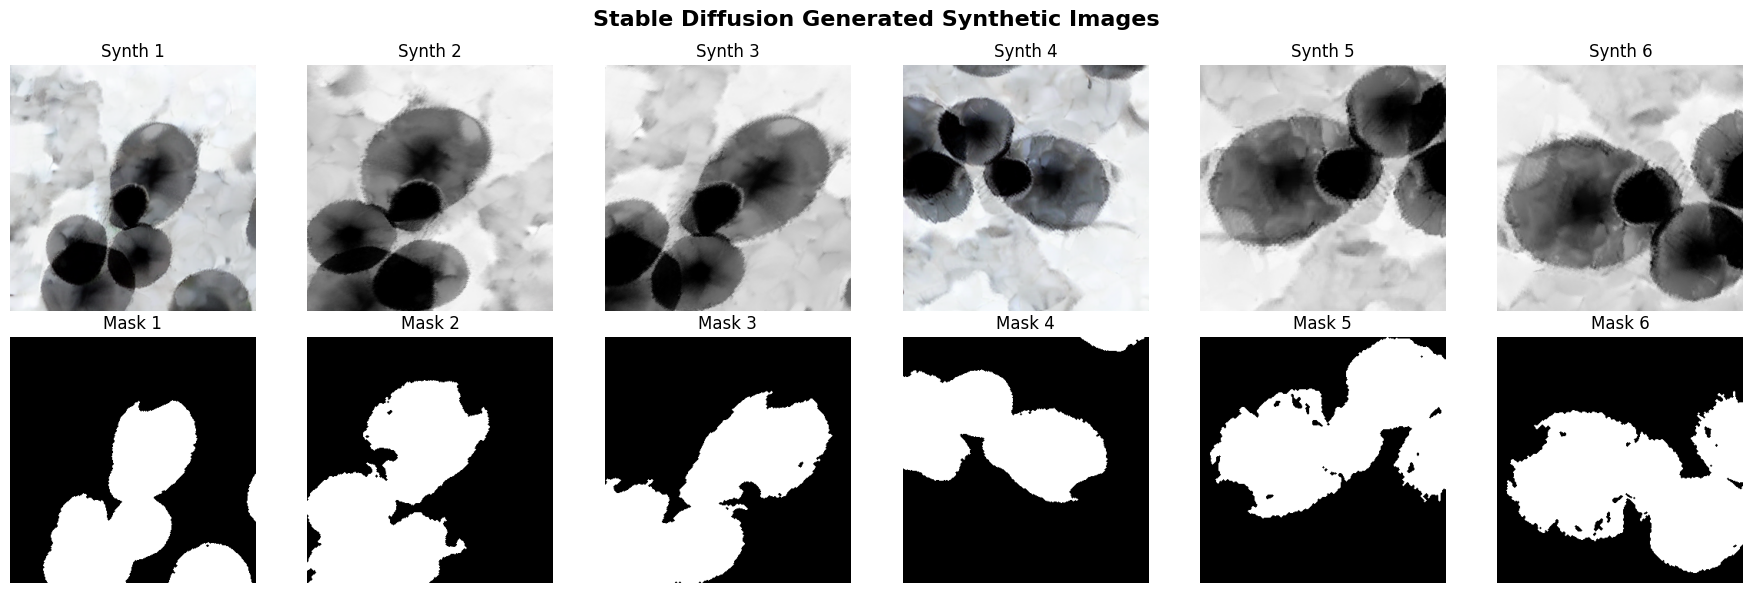


Displayed 6 synthetic images
Total images generated: 30


In [6]:
# Load and display generated images
output_images_dir = prep_manager_sdiff.output_images_dir
output_masks_dir = prep_manager_sdiff.output_bin_masks_dir

# Get list of generated files
image_files = sorted([f for f in os.listdir(output_images_dir) if f.endswith('.png')])[:6]

# Create visualization
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Stable Diffusion Generated Synthetic Images', fontsize=16, fontweight='bold')

for idx, img_file in enumerate(image_files):
    # Load image and mask
    img_path = os.path.join(output_images_dir, img_file)
    mask_path = os.path.join(output_masks_dir, img_file)
    
    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))
    
    # Display image
    axes[0, idx].imshow(img, cmap='gray')
    axes[0, idx].set_title(f'Synth {idx+1}')
    axes[0, idx].axis('off')
    
    # Display mask
    axes[1, idx].imshow(mask, cmap='gray')
    axes[1, idx].set_title(f'Mask {idx+1}')
    axes[1, idx].axis('off')

plt.tight_layout()
plt.show()

print(f"\nDisplayed {len(image_files)} synthetic images")
print(f"Total images generated: {len(os.listdir(output_images_dir))}")